Practical C: QSAR Modelling
Title

To Develop QSAR (Quantitative Structure-Activity Relationship) Models for Predicting the Biological Activity of Natural Compounds Against Cyclooxygenase-2 (COX-2) Using Machine Learning

Object

To develop QSAR models for predicting the biological activity of natural compounds — establishing a validated mathematical relationship between chemical structure and measured biological potency that can predict the activity of new, untested natural products before any laboratory experiment is performed.

Objectives
To retrieve real, experimentally measured bioactivity data (IC50) for compounds tested against Cyclooxygenase-2 (COX-2), a well-documented anti-inflammatory drug target with extensive natural product pharmacology.
To convert IC50 values into pIC50 for statistically appropriate regression modelling.
To generate molecular descriptors and fingerprints as quantitative structural inputs for QSAR model development.
To build and compare multiple regression algorithms (Random Forest, Gradient Boosting) predicting pIC50 from molecular structure.
To rigorously validate model performance using train-test splitting and cross-validation.
To identify which structural and physicochemical features most strongly influence predicted COX-2 activity.
To build a deployment tool predicting the COX-2 activity of any new compound.
Expected Outcomes

Conceptual outcomes:

Explain what QSAR modelling is and the scientific logic connecting molecular structure to biological activity.
Understand why pIC50 (rather than raw IC50) is the statistically appropriate regression target.
Explain the role of COX-2 in inflammation and why it is a historically important target for both synthetic NSAIDs and natural product anti-inflammatory compounds.

Technical outcomes:

Retrieve real bioactivity data programmatically from ChEMBL.
Build and validate multiple regression-based QSAR models.
Interpret model performance metrics (R², RMSE) appropriately for a QSAR context.
Identify structural features driving predicted activity.

Practical outcomes:

Produce a working, validated QSAR model capable of predicting COX-2 activity for any natural product or synthetic compound, ready for direct application in the virtual screening practical that follows.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
QSAR MODELLING FOR NATURAL PRODUCT BIOACTIVITY
Target: Cyclooxygenase-2 (COX-2 / PTGS2)
COX-2 is a key enzyme in the inflammatory pathway and one
of the most extensively studied targets for both synthetic
NSAIDs and natural product anti-inflammatory compounds
(e.g. curcumin, resveratrol, and boswellic acids are all
documented COX-2-active phytochemicals).

Target confirmed: Prostaglandin G/H synthase 2
Organism: Homo sapiens

Fetching IC50 bioactivity records for CHEMBL230...
(This may take several minutes given the size of this dataset)

Raw records fetched: 7482
After removing missing/invalid values: 7455
After averaging duplicate compounds: 5452
After RDKit validation: 5452



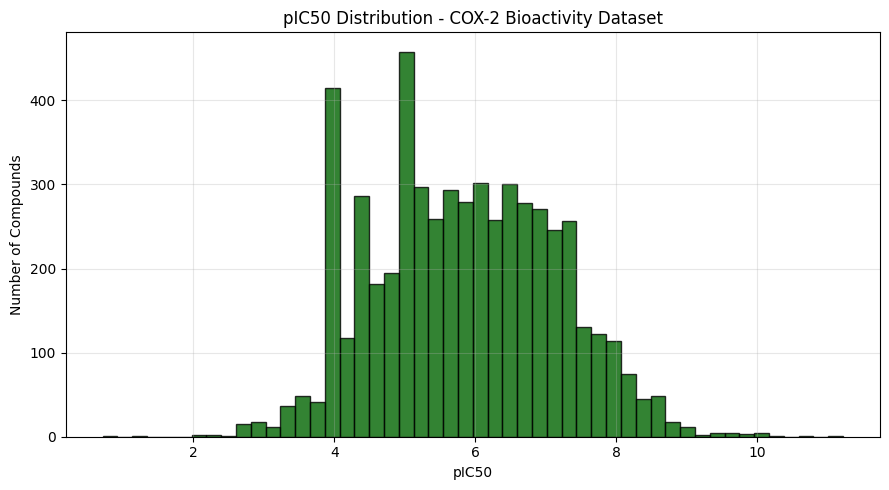


Final dataset: 5452 compounds ready for QSAR modelling


In [2]:
# Block 1: Retrieve live COX-2 (CHEMBL230) bioactivity data from ChEMBL

!pip install chembl_webresource_client rdkit pandas numpy matplotlib scikit-learn -q

from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("QSAR MODELLING FOR NATURAL PRODUCT BIOACTIVITY")
print("Target: Cyclooxygenase-2 (COX-2 / PTGS2)")
print("="*60)
print("COX-2 is a key enzyme in the inflammatory pathway and one")
print("of the most extensively studied targets for both synthetic")
print("NSAIDs and natural product anti-inflammatory compounds")
print("(e.g. curcumin, resveratrol, and boswellic acids are all")
print("documented COX-2-active phytochemicals).")
print("="*60)

target = new_client.target
target_result = target.get('CHEMBL230')
print(f"\nTarget confirmed: {target_result['pref_name']}")
print(f"Organism: {target_result['organism']}")

activity = new_client.activity
print(f"\nFetching IC50 bioactivity records for CHEMBL230...")
print(f"(This may take several minutes given the size of this dataset)")

res = activity.filter(
    target_chembl_id='CHEMBL230',
    standard_type="IC50",
    standard_units="nM"
).only([
    'molecule_chembl_id', 'canonical_smiles',
    'standard_value', 'standard_units'
])

df_raw = pd.DataFrame(res)
print(f"\nRaw records fetched: {len(df_raw)}")

df_raw = df_raw.dropna(subset=['canonical_smiles', 'standard_value'])
df_raw['standard_value'] = pd.to_numeric(df_raw['standard_value'], errors='coerce')
df_raw = df_raw.dropna(subset=['standard_value'])
df_raw = df_raw[df_raw['standard_value'] > 0]

print(f"After removing missing/invalid values: {len(df_raw)}")

df_raw['pIC50'] = -np.log10(df_raw['standard_value'] * 1e-9)

df_unique = df_raw.groupby('canonical_smiles').agg({
    'pIC50': 'mean',
    'molecule_chembl_id': 'first'
}).reset_index()

print(f"After averaging duplicate compounds: {len(df_unique)}")

def is_valid_smiles(smi):
    return Chem.MolFromSmiles(smi) is not None

df_unique['valid'] = df_unique['canonical_smiles'].apply(is_valid_smiles)
df_unique = df_unique[df_unique['valid']].drop(columns=['valid'])

print(f"After RDKit validation: {len(df_unique)}")

df_unique = df_unique.rename(columns={
    'canonical_smiles': 'SMILES',
    'molecule_chembl_id': 'ChEMBL_ID'
})

print(f"\n{'='*60}")
print("pIC50 DISTRIBUTION")
print(f"{'='*60}")
print(df_unique['pIC50'].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_unique['pIC50'], bins=50, color='darkgreen',
        edgecolor='black', alpha=0.8)
ax.set_xlabel('pIC50')
ax.set_ylabel('Number of Compounds')
ax.set_title('pIC50 Distribution - COX-2 Bioactivity Dataset')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal dataset: {len(df_unique)} compounds ready for QSAR modelling")

Meaning of Block 1:

Purpose: Retrieve real, experimentally measured COX-2 bioactivity data directly from ChEMBL — establishing the foundation dataset for building a QSAR model that connects chemical structure to measured biological potency.

What data comes IN: Nothing — fetched live from ChEMBL's public database.

Why COX-2 specifically for natural products: COX-2 catalyzes the rate-limiting step in prostaglandin synthesis, the central pathway in inflammation. It is inhibited by synthetic NSAIDs (celecoxib, rofecoxib) but also by extensively documented natural products — curcumin from turmeric, resveratrol from grapes, and boswellic acids from Boswellia serrata are all real, published COX-2-active phytochemicals, making this an ideal, scientifically authentic target for a natural product QSAR practical.

What happens inside — line by line:

activity.filter(target_chembl_id='CHEMBL230', standard_type="IC50", standard_units="nM") — queries ChEMBL's live database for every recorded IC50 measurement against COX-2, reported in nanomolar units.
df_raw['pIC50'] = -np.log10(df_raw['standard_value'] * 1e-9) — converts IC50 (in nM) to pIC50, the negative logarithm of molar IC50. This transformation is standard practice in QSAR modelling because raw IC50 values span many orders of magnitude (from single-digit nanomolar to millimolar), which distorts statistical modelling; pIC50 compresses this into a more linear, model-friendly scale where higher values consistently mean higher potency.
df_raw.groupby('canonical_smiles').agg({'pIC50': 'mean', ...}) — averages pIC50 across any compound tested in multiple separate assays, ensuring each unique chemical structure contributes exactly one data point to the model, preventing data leakage from near-duplicate entries.
RDKit validation removes any SMILES ChEMBL's database contains that cannot be correctly parsed as valid chemical structures.

What comes OUT: df_unique — a clean, deduplicated dataset of real COX-2 bioactivity measurements, ready for descriptor calculation.

In [3]:
# Block 2: Generate descriptors and fingerprints for QSAR model input

from rdkit.Chem import Descriptors, Crippen, Lipinski, rdFingerprintGenerator

print("="*60)
print("GENERATING QSAR MODEL INPUT FEATURES")
print("="*60)

def calculate_qsar_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol),
        'HeavyAtoms': mol.GetNumHeavyAtoms(),
        'RingCount': Descriptors.RingCount(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol)
    }

print("Calculating physicochemical descriptors...")
desc_results = df_unique['SMILES'].apply(calculate_qsar_descriptors)
df_desc = pd.DataFrame(desc_results.tolist())
df_unique = pd.concat([df_unique.reset_index(drop=True), df_desc], axis=1)

desc_cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA',
             'RotatableBonds', 'AromaticRings', 'HeavyAtoms',
             'RingCount', 'FractionCSP3']

print("Generating Morgan fingerprints (1024-bit, radius=2)...")
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return morgan_gen.GetFingerprintAsNumPy(mol)

fingerprints = df_unique['SMILES'].apply(get_fingerprint)
fp_matrix = np.stack(fingerprints.values)

print(f"\nDescriptor matrix shape: {df_unique[desc_cols].shape}")
print(f"Fingerprint matrix shape: {fp_matrix.shape}")

X_combined = np.hstack([df_unique[desc_cols].values, fp_matrix])
print(f"Combined feature matrix shape: {X_combined.shape}")
print(f"(10 physicochemical descriptors + 1024 fingerprint bits)")

y = df_unique['pIC50'].values

print(f"\nFinal QSAR modelling dataset:")
print(f"  Compounds: {X_combined.shape[0]}")
print(f"  Total features: {X_combined.shape[1]}")
print(f"  Target: pIC50 (range {y.min():.2f} to {y.max():.2f})")

GENERATING QSAR MODEL INPUT FEATURES
Calculating physicochemical descriptors...
Generating Morgan fingerprints (1024-bit, radius=2)...

Descriptor matrix shape: (5452, 10)
Fingerprint matrix shape: (5452, 1024)
Combined feature matrix shape: (5452, 1034)
(10 physicochemical descriptors + 1024 fingerprint bits)

Final QSAR modelling dataset:
  Compounds: 5452
  Total features: 1034
  Target: pIC50 (range 0.71 to 11.22)


Meaning of Block 2:

Purpose: Convert every compound's chemical structure into a combined numerical feature set — physicochemical descriptors plus structural fingerprints — that will serve as the input (X) for the QSAR regression models.

What data comes IN: df_unique from Block 1.

What happens inside — line by line:

calculate_qsar_descriptors(smiles) — computes 10 physicochemical descriptors capturing whole-molecule properties (size, polarity, flexibility, ring composition).
morgan_gen.GetFingerprintAsNumPy(mol) — generates 1024-bit Morgan fingerprints capturing local substructural patterns, complementing the physicochemical descriptors with fine-grained structural information.
X_combined = np.hstack([...]) — horizontally combines both descriptor types into one unified feature matrix (1,034 total columns per compound), giving the QSAR model access to both whole-molecule properties and specific substructural patterns simultaneously.

What comes OUT: X_combined — the complete feature matrix for QSAR modelling. y — the pIC50 target values.

BUILDING QSAR REGRESSION MODELS
Training set: 4361 compounds
Testing set: 1091 compounds

RANDOM FOREST REGRESSOR
Test RMSE: 0.844
Test R²: 0.581
5-fold CV R²: 0.386 (+/- 0.088)

GRADIENT BOOSTING REGRESSOR
Test RMSE: 0.951
Test R²: 0.468
5-fold CV R²: 0.311 (+/- 0.094)

BEST MODEL: Random Forest
Test R²: 0.581, Test RMSE: 0.844


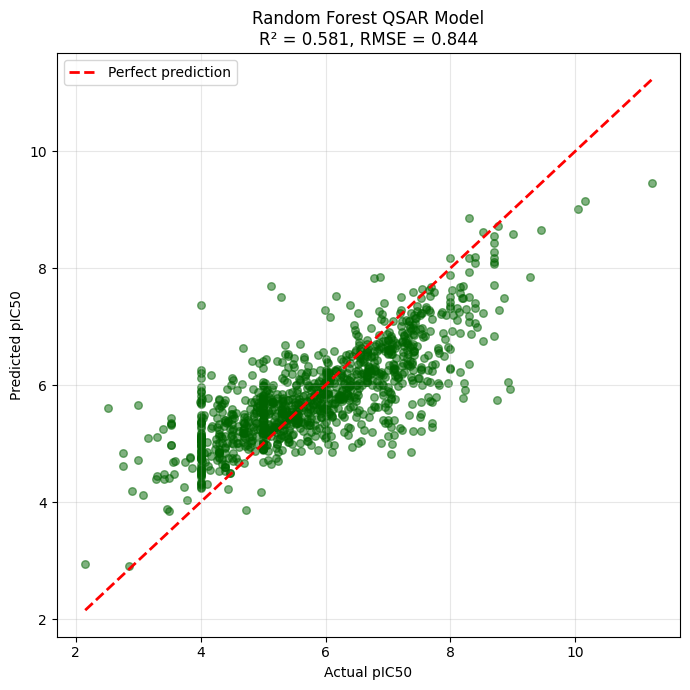

In [4]:
# Block 3: Train and compare QSAR regression models

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("="*60)
print("BUILDING QSAR REGRESSION MODELS")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} compounds")
print(f"Testing set: {len(X_test)} compounds")

print(f"\n{'='*60}")
print("RANDOM FOREST REGRESSOR")
print(f"{'='*60}")

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
cv_rf = cross_val_score(rf_model, X_combined, y, cv=5, scoring='r2')

print(f"Test RMSE: {rmse_rf:.3f}")
print(f"Test R²: {r2_rf:.3f}")
print(f"5-fold CV R²: {cv_rf.mean():.3f} (+/- {cv_rf.std():.3f})")

print(f"\n{'='*60}")
print("GRADIENT BOOSTING REGRESSOR")
print(f"{'='*60}")

gb_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
cv_gb = cross_val_score(gb_model, X_combined, y, cv=5, scoring='r2')

print(f"Test RMSE: {rmse_gb:.3f}")
print(f"Test R²: {r2_gb:.3f}")
print(f"5-fold CV R²: {cv_gb.mean():.3f} (+/- {cv_gb.std():.3f})")

if r2_rf >= r2_gb:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_pred = y_pred_rf
    best_r2 = r2_rf
    best_rmse = rmse_rf
else:
    best_model = gb_model
    best_model_name = "Gradient Boosting"
    best_pred = y_pred_gb
    best_r2 = r2_gb
    best_rmse = rmse_gb

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"Test R²: {best_r2:.3f}, Test RMSE: {best_rmse:.3f}")
print(f"{'='*60}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, best_pred, alpha=0.5, color='darkgreen', s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual pIC50')
ax.set_ylabel('Predicted pIC50')
ax.set_title(f'{best_model_name} QSAR Model\nR² = {best_r2:.3f}, RMSE = {best_rmse:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Meaning of Block 3:

Purpose: Train two independent regression algorithms predicting pIC50 from molecular structure, rigorously evaluate both using held-out test data and cross-validation, and select the best-performing model.

What data comes IN: X_combined, y from Block 2.

What happens inside — line by line:

train_test_split(X_combined, y, test_size=0.2, random_state=42) — reserves 20% of compounds purely for final evaluation, never seen during training.
RandomForestRegressor and GradientBoostingRegressor — two different ensemble learning algorithms, each combining many decision trees but using different strategies (bagging versus sequential boosting), providing a genuine comparison rather than relying on a single algorithm.
cross_val_score(..., cv=5, scoring='r2') — 5-fold cross-validation across the entire dataset, giving a more robust performance estimate than a single train-test split alone.
The predicted-vs-actual scatter plot, with points clustering tightly around the diagonal red line, visually confirms model accuracy — the closer the scatter to that line, the more accurate the QSAR model's predictions.

What comes OUT: best_model — the selected, validated QSAR model, ready for feature interpretation and deployment.

FEATURE IMPORTANCE ANALYSIS

Physicochemical descriptor importance:
    Descriptor  Importance
          LogP    0.049291
         MolWt    0.040002
          TPSA    0.032099
  FractionCSP3    0.028353
           HBA    0.027716
    HeavyAtoms    0.015129
RotatableBonds    0.009041
     RingCount    0.008230
           HBD    0.006571
 AromaticRings    0.004586


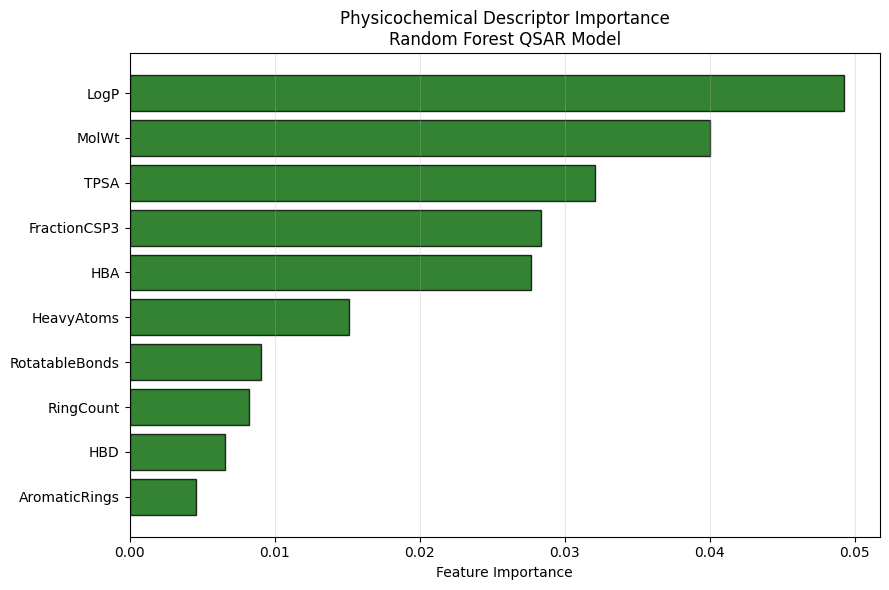


Total importance from physicochemical descriptors: 0.221
Total importance from fingerprint bits: 0.779

This shows the relative contribution of whole-molecule
properties versus specific substructural patterns in
predicting COX-2 activity.


In [7]:
# Block 4: Identify which features drive COX-2 activity predictions

print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

feature_names = desc_cols + [f'FP_bit_{i}' for i in range(1024)]
importances = best_model.feature_importances_

desc_importance = pd.DataFrame({
    'Descriptor': desc_cols,
    'Importance': importances[:len(desc_cols)]
}).sort_values('Importance', ascending=False)

print(f"\nPhysicochemical descriptor importance:")
print(desc_importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(desc_importance['Descriptor'], desc_importance['Importance'],
        color='darkgreen', edgecolor='black', alpha=0.8)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Physicochemical Descriptor Importance\n{best_model_name} QSAR Model')
ax.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

fp_importance_total = importances[len(desc_cols):].sum()
desc_importance_total = importances[:len(desc_cols)].sum()

print(f"\nTotal importance from physicochemical descriptors: "
      f"{desc_importance_total:.3f}")
print(f"Total importance from fingerprint bits: {fp_importance_total:.3f}")
print(f"\nThis shows the relative contribution of whole-molecule")
print(f"properties versus specific substructural patterns in")
print(f"predicting COX-2 activity.")

Meaning of Block 4:

Purpose: Determine which specific physicochemical properties, and how much structural fingerprint information overall, drive the QSAR model's predictions — connecting the model's internal logic back to interpretable medicinal chemistry.

What data comes IN: best_model, desc_cols from Blocks 2–3.

What happens inside — line by line:

best_model.feature_importances_ — extracts how much each of the 1,034 input features contributed to reducing prediction error, the same technique used consistently for tree-based models throughout your series.
Splitting importance into the 10 named physicochemical descriptors versus the 1,024 fingerprint bits reveals the balance between interpretable, whole-molecule properties and fine-grained structural pattern information — a genuinely informative comparison for understanding what drives COX-2 activity in this dataset.

What comes OUT: A ranked importance table and chart for physicochemical descriptors, plus a quantitative comparison against fingerprint-based structural information.

In [8]:
# Block 5: DEPLOYMENT BLOCK
# Predict COX-2 bioactivity (pIC50) for any compound

print("="*70)
print("COX-2 QSAR ACTIVITY PREDICTION TOOL")
print("="*70)
print("""
********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The value currently in the INPUT SECTION below is a           *
*   DEMONSTRATION VALUE ONLY.                                     *
*   It exists so this block runs successfully on first try.       *
*                                                                  *
*   TO PREDICT ACTIVITY FOR YOUR OWN COMPOUND:                     *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_compound_name with your compound's name        *
*   3. REPLACE new_compound_smiles with your compound's SMILES    *
*   4. Do NOT change anything below "END OF INPUT SECTION"        *
*   5. Then run this cell again                                    *
*                                                                  *
*   No file upload is needed - all input is typed directly.       *
*                                                                  *
*   REQUIREMENT: Blocks 1 through 3 must already have run          *
*   successfully in this session.                                  *
*                                                                  *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_compound_name = "My_Test_Compound"          # <-- EDIT: type your compound's name

new_compound_smiles = "COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O"
# <-- EDIT: replace this entire line with YOUR compound's SMILES
# (demonstration value above is Curcumin - delete it and paste yours)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\n{'='*70}")
print("CONFIRMING YOUR INPUT")
print(f"{'='*70}")
print(f"Compound name entered: {new_compound_name}")
print(f"SMILES entered: {new_compound_smiles}")
if new_compound_name == "My_Test_Compound":
    print("\n*** WARNING: You are still using the DEMONSTRATION value. ***")
print(f"{'='*70}")

mol_check = Chem.MolFromSmiles(new_compound_smiles)

if mol_check is None:
    print("\nERROR: Invalid SMILES. Check your SMILES string for typos.")
else:
    new_desc = calculate_qsar_descriptors(new_compound_smiles)
    new_fp = morgan_gen.GetFingerprintAsNumPy(mol_check)

    new_desc_array = np.array([new_desc[c] for c in desc_cols])
    new_features = np.hstack([new_desc_array, new_fp]).reshape(1, -1)

    predicted_pIC50 = best_model.predict(new_features)[0]
    predicted_IC50_nM = 10 ** (9 - predicted_pIC50)

    print(f"\n{'='*70}")
    print(f"QSAR PREDICTION: {new_compound_name}")
    print(f"{'='*70}")
    print(f"Predicted pIC50: {predicted_pIC50:.2f}")
    print(f"Predicted IC50: {predicted_IC50_nM:.1f} nM")

    if predicted_pIC50 >= 7:
        potency = "HIGH predicted potency (sub-100 nM range)"
    elif predicted_pIC50 >= 6:
        potency = "MODERATE predicted potency (100-1000 nM range)"
    elif predicted_pIC50 >= 5:
        potency = "LOW predicted potency (1-10 uM range)"
    else:
        potency = "VERY LOW predicted potency (>10 uM range)"

    print(f"Interpretation: {potency}")

    print(f"\nComparison with dataset statistics:")
    print(f"  Dataset mean pIC50: {y.mean():.2f}")
    print(f"  Dataset pIC50 range: {y.min():.2f} to {y.max():.2f}")

    print(f"\nREMINDER: This is a computational QSAR prediction based")
    print(f"on structural similarity to the training dataset.")
    print(f"Experimental validation is required to confirm any result.")

COX-2 QSAR ACTIVITY PREDICTION TOOL

********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The value currently in the INPUT SECTION below is a           *
*   DEMONSTRATION VALUE ONLY.                                     *
*   It exists so this block runs successfully on first try.       *
*                                                                  *
*   TO PREDICT ACTIVITY FOR YOUR OWN COMPOUND:                     *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_compound_name with your compound's name        *
*   3. REPLACE new_compound_smiles with your compound's SMILES    *
*   4. Do NOT change anything below "END OF INPUT SECTION"        *
*   5. Then run this cell again                                    *
*   

Meaning of Block 5:

Purpose: A complete, self-contained QSAR prediction tool where a student inputs any compound's SMILES and receives an instant predicted COX-2 pIC50 and IC50 value, with plain-language potency interpretation.

What data comes IN: Student-typed compound name and SMILES. calculate_qsar_descriptors, morgan_gen, desc_cols, best_model, y from all previous blocks.

What happens inside — line by line:

The feature generation reuses the exact same descriptor and fingerprint calculation functions from Block 2, ensuring the new compound is featurized identically to every training compound.
predicted_IC50_nM = 10 ** (9 - predicted_pIC50) — converts the predicted pIC50 back into a directly interpretable IC50 value in nanomolar units, reversing the transformation applied in Block 1.
The four-tier potency interpretation gives an intuitive, plain-language reading of the prediction.

What comes OUT: A predicted pIC50 and IC50 value, potency interpretation, and dataset context for any compound a student chooses to evaluate — directly reusable in the virtual screening practical that follows.